In [1]:
# prompt: install and import open dataset as od and download https://www.kaggle.com/datasets/saurabhshahane/mango-varieties-classification

!pip install opendatasets
import opendatasets as od

dataset_url = 'https://www.kaggle.com/datasets/jiscecseaiml/fish-classification-dataset'

od.download(dataset_url)



Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: kazitanvir
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/jiscecseaiml/fish-classification-dataset


100%|██████████| 9.26G/9.26G [07:17<00:00, 22.7MB/s]


In [2]:
!pip install Keras
!pip install vit-keras
!pip install tensorflow-addons
!pip install opendatasets
import opendatasets as od
import pandas

import os

import keras.preprocessing
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras

from keras.preprocessing import image
from keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from keras import layers
from keras import regularizers, activations
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from keras.callbacks import ModelCheckpoint
from keras.layers import Dense, Dropout, Flatten, Activation, Concatenate, Lambda
from keras.layers import Input, Conv2D, MaxPooling2D, GlobalAveragePooling2D, BatchNormalization, ZeroPadding2D
from keras.models import Model
from keras.optimizers import Adam
from keras.applications import ResNet50V2
from keras.preprocessing.image import ImageDataGenerator
from vit_keras import vit, utils


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.8/611.8 kB 12.0 MB/s eta 0:00:00


/usr/local/lib/python3.10/dist-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(


In [3]:
!pip install alibi-detect

from tensorflow.keras.layers import Conv2D, Conv2DTranspose, Dense, Reshape, InputLayer, Flatten
from alibi_detect.od import OutlierVAE

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 381.5/381.5 kB 9.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 15.2 MB/s eta 0:00:00


In [4]:
from PIL import Image
import os

def resize_images_in_folder(input_folder, output_folder, target_size=(224, 224)):
    # Create the output folder if it doesn't exist
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    # Loop through all files in the input folder
    for filename in os.listdir(input_folder):
        # Check if the file is an image
        if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.gif')):
            # Open the image file
            with Image.open(os.path.join(input_folder, filename)) as img:
                # Resize the image
                resized_img = img.resize(target_size)
                # Save the resized image to the output folder
                resized_img.save(os.path.join(output_folder, filename))

def resize_images_in_main_folder(main_folder, output_main_folder, target_size=(224, 224)):
    # Iterate through all subfolders in the main folder
    for subfolder in os.listdir(main_folder):
        input_folder = os.path.join(main_folder, subfolder)
        output_folder = os.path.join(output_main_folder, subfolder)
        # Resize images in each subfolder
        resize_images_in_folder(input_folder, output_folder, target_size)

# Specify the main folder containing subfolders
main_folder = '/content/fish-classification-dataset/Training'
output_main_folder = '/content/resized2/'

# Call the function to resize images in each subfolder
resize_images_in_main_folder(main_folder, output_main_folder)

In [5]:
base_dir = '/content/resized2'

In [6]:
import os
import cv2
from tqdm import tqdm

def invert_colors(input_folder, output_folder):
    # List all files in the directory tree at given path
    files_to_process = []
    for root, dirs, files in os.walk(input_folder):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                files_to_process.append((root, file))

    # Initialize tqdm progress bar
    for root, file in tqdm(files_to_process, desc="Inverting colors"):
        # Create input and output file paths
        input_image_path = os.path.join(root, file)
        output_image_path = os.path.join(output_folder, os.path.relpath(input_image_path, input_folder))

        # Read the image
        image = cv2.imread(input_image_path)

        # Invert the colors
        inverted_image = ~image

        # Ensure the output directory exists
        os.makedirs(os.path.dirname(output_image_path), exist_ok=True)

        # Save the inverted image
        cv2.imwrite(output_image_path, inverted_image)

# Example usage:
input_folder = base_dir
output_folder = "/content/Invert"
invert_colors(input_folder, output_folder)




Inverting colors: 100%|██████████| 3139/3139 [00:13<00:00, 235.29it/s]


In [7]:
base_dir = '/content/Invert'

In [8]:
import os

def get_folder_names(directory_path):
    # Initialize an empty list to store folder names
    folder_names = []

    # Iterate over items in the specified directory
    for item in os.listdir(directory_path):
        item_path = os.path.join(directory_path, item)

        # Check if the item is a directory
        if os.path.isdir(item_path):
          if item != '.ipynb_checkpoints':
            folder_names.append(item)

    return folder_names

# Specify the directory path for which you want to fetch folder names
directory_path = base_dir

# Call the function to get folder names in the specified directory
folders = get_folder_names(directory_path)

# Print the list of folder names
print("Folder Names:", folders)


Folder Names: ['Fresh_Gills', 'Nonfresh_Gills', 'Fresh_Eyes', 'Nonfresh_Eyes']


In [9]:
import numpy as np
import sys

# Monkey-patch numpy to use np.bool_
sys.modules['numpy'].bool = np.bool_

import os
import random
from tqdm import tqdm
from PIL import Image
import imgaug.augmenters as iaa

def augment_image(image, augmenter):
    image_np = np.array(image)
    augmented_image_np = augmenter(image=image_np)
    augmented_image = Image.fromarray(augmented_image_np)
    return augmented_image

def augment_images(source_directory, output_directory, target_count):
    # Define the augmentation pipeline using imgaug
    augmenter = iaa.Sequential([
        iaa.SomeOf((1, 4), [
            iaa.Fliplr(0.5),  # horizontal flips
            iaa.Affine(rotate=(-20, 20)),  # rotations
            iaa.Affine(scale=(0.8, 1.2)),  # zoom
            iaa.Affine(translate_percent={"x": (-0.2, 0.2), "y": (-0.2, 0.2)}),  # translations
            iaa.AdditiveGaussianNoise(scale=(10, 20)),  # Gaussian noise
            iaa.Multiply((0.8, 1.7)),  # brightness
            iaa.LinearContrast((0.8, 1.7))  # contrast
        ])
    ])

    # Ensure the destination directory exists; create it if necessary
    if not os.path.exists(output_directory):
        os.makedirs(output_directory)

    # Get the list of files in the source directory
    image_files = [f for f in os.listdir(source_directory) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'))]

    # Calculate the number of additional images needed
    existing_images = len(image_files)
    images_per_original = max(1, target_count // existing_images)

    # Augment images until the target count is reached
    for filename in tqdm(image_files, desc=f"Augmenting images in {source_directory}"):
        img_path = os.path.join(source_directory, filename)
        img = Image.open(img_path)

        # Save the original image to the output directory
        img.save(os.path.join(output_directory, f'orig_{filename}'))

        # Generate augmented images
        for i in range(images_per_original):
            augmented_image = augment_image(img, augmenter)
            augmented_image.save(os.path.join(output_directory, f'aug_{i}_{filename}'))

    # Remove excess images from the output directory
    output_images = os.listdir(output_directory)
    if len(output_images) > target_count:
        for i in range(len(output_images) - target_count):
            os.remove(os.path.join(output_directory, output_images[i]))

    print(f"Augmentation complete for {source_directory}. Total images in '{output_directory}': {len(os.listdir(output_directory))}")

# Specify the root directory containing subfolders
root_directory = base_dir  # Change this to your actual base directory

# Find the maximum number of images in any class
max_images = 3000
for subfolder in os.listdir(root_directory):
    subfolder_path = os.path.join(root_directory, subfolder)
    if os.path.isdir(subfolder_path):
        num_images = len([f for f in os.listdir(subfolder_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'))])
        if num_images > max_images:
            max_images = num_images

# Iterate through subfolders and augment images to match the maximum count
for subfolder in os.listdir(root_directory):
    subfolder_path = os.path.join(root_directory, subfolder)
    if os.path.isdir(subfolder_path):
        # Define source and output directories for the current subfolder
        source_directory = subfolder_path
        output_directory = os.path.join('/content/augmented2', subfolder)

        # Call the augment_images function for the current subfolder
        augment_images(source_directory, output_directory, target_count=max_images)


Augmenting images in /content/Invert/Fresh_Gills: 100%|██████████| 613/613 [00:09<00:00, 64.40it/s]


Augmentation complete for /content/Invert/Fresh_Gills. Total images in '/content/augmented2/Fresh_Gills': 3000


Augmenting images in /content/Invert/Nonfresh_Gills: 100%|██████████| 1265/1265 [00:08<00:00, 143.19it/s]


Augmentation complete for /content/Invert/Nonfresh_Gills. Total images in '/content/augmented2/Nonfresh_Gills': 3000


Augmenting images in /content/Invert/Fresh_Eyes: 100%|██████████| 233/233 [00:08<00:00, 26.05it/s]


Augmentation complete for /content/Invert/Fresh_Eyes. Total images in '/content/augmented2/Fresh_Eyes': 3000


Augmenting images in /content/Invert/Nonfresh_Eyes: 100%|██████████| 1028/1028 [00:06<00:00, 152.27it/s]

Augmentation complete for /content/Invert/Nonfresh_Eyes. Total images in '/content/augmented2/Nonfresh_Eyes': 3000


In [10]:
import os
import cv2
import numpy as np

# Function to detect outliers using IQR method
def detect_outliers_iqr(data, threshold=1.5):
    q25, q75 = np.percentile(data, 25), np.percentile(data, 75)
    iqr = q75 - q25
    cut_off = iqr * threshold
    lower, upper = q25 - cut_off, q75 + cut_off
    outliers = [x for x in data if x < lower or x > upper]
    return outliers

# Function to handle outliers in an image
def handle_outliers(image):
    # Convert the image to grayscale
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    # Flatten the image into a 1D array
    flattened_image = gray_image.flatten()
    # Detect outliers in the flattened image
    outliers = detect_outliers_iqr(flattened_image)
    # Replace outliers with median value
    median_value = np.median(flattened_image)
    cleaned_image = np.where(np.isin(flattened_image, outliers), median_value, flattened_image)
    # Reshape the flattened image back to its original shape
    cleaned_image = cleaned_image.reshape(gray_image.shape)
    return cleaned_image

# Root directory
root_dir = "/content/augmented2"

# Iterate through each subfolder
for subdir in os.listdir(root_dir):
    subdir_path = os.path.join(root_dir, subdir)
    if os.path.isdir(subdir_path):
        print("Processing subfolder:", subdir)
        # Iterate through each file in the subfolder
        for file_name in os.listdir(subdir_path):
            file_path = os.path.join(subdir_path, file_name)
            if file_name.endswith(('.jpg', '.jpeg', '.png')):
                print("Processing file:", file_name)
                # Load the image
                image = cv2.imread(file_path)
                # Handling outliers
                cleaned_image = handle_outliers(image)
                # Save the cleaned image
                cleaned_file_path = os.path.join(subdir_path, "cleaned_" + file_name)
                cv2.imwrite(cleaned_file_path, cleaned_image)
                print("Cleaned image saved at:", cleaned_file_path)


Processing subfolder: Fresh_Gills
Processing subfolder: Nonfresh_Gills
Processing subfolder: Fresh_Eyes
Processing subfolder: Nonfresh_Eyes


In [11]:
base_dir = '/content/augmented2'

In [12]:
train_dir = os.path.join(base_dir, 'train')
os.makedirs(train_dir, exist_ok=True)


test_dir = os.path.join(base_dir, 'test')
os.makedirs(test_dir, exist_ok=True)

In [13]:

import shutil

# List of class folder names
class_folders = folders
# Split ratios (adjust these as needed)
train_ratio = 0.9
test_ratio = 0.1

for folder in class_folders:
    source_folder = os.path.join(base_dir, folder)
    train_dest = os.path.join(train_dir, folder)
    test_dest = os.path.join(test_dir, folder)

    os.makedirs(train_dest, exist_ok=True)
    os.makedirs(test_dest, exist_ok=True)

    filenames = os.listdir(source_folder)
    num_files = len(filenames)

    num_train = int(num_files * train_ratio)

    train_files = filenames[:num_train]
    test_files = filenames[num_train:]

    for file in train_files:
        src_path = os.path.join(source_folder, file)
        dest_path = os.path.join(train_dest, file)
        shutil.copy(src_path, dest_path)


    for file in test_files:
        src_path = os.path.join(source_folder, file)
        dest_path = os.path.join(test_dest, file)
        shutil.copy(src_path, dest_path)



In [14]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

size = 224
batch_size = 64
target_size = (size, size)  # Adjust as needed

# Training data generator with validation split
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.112)  # 20% of the data will be used for validation

# Train generator
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=target_size,
    class_mode='categorical',
    batch_size=batch_size,
    subset='training')  # Use the training subset

# Validation generator from the training data
validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=target_size,
    class_mode='categorical',
    batch_size=batch_size,
    subset='validation')  # Use the validation subset

# Test data generator
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=target_size,
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False)



Found 9592 images belonging to 4 classes.
Found 1208 images belonging to 4 classes.
Found 1200 images belonging to 4 classes.


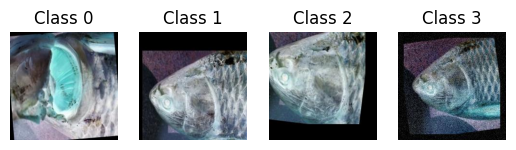

In [15]:
# prompt: print the 1 image from each class from train generator

import matplotlib.pyplot as plt

# Get the number of classes
num_classes = len(train_generator.class_indices)

# Initialize a figure with subplots
fig, axs = plt.subplots(1, num_classes)

# Iterate over each class
for i in range(num_classes):
    # Get the first image from the class
    image, label = train_generator.next()
    image = image[0]

    # Display the image
    axs[i].imshow(image)
    axs[i].axis('off')
    axs[i].set_title(f"Class {i}")

# Show the plot
plt.show()


In [44]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense, Flatten, Input
from tensorflow.keras.models import Model
from tensorflow.keras.applications import VGG19	, ConvNeXtTiny

# Custom GroupNormalization layer
class GroupNormalization(layers.Layer):
    def __init__(self, groups=32, **kwargs):
        super(GroupNormalization, self).__init__(**kwargs)
        self.groups = groups

    def build(self, input_shape):
        self.scale = self.add_weight(name='scale', shape=(input_shape[-1],),
                                     initializer='ones', trainable=True)
        self.offset = self.add_weight(name='offset', shape=(input_shape[-1],),
                                      initializer='zeros', trainable=True)

    def call(self, inputs):
        input_shape = tf.shape(inputs)
        group_shape = tf.concat([input_shape[:-1], [self.groups, input_shape[-1] // self.groups]], axis=0)
        grouped_inputs = tf.reshape(inputs, group_shape)
        mean, variance = tf.nn.moments(grouped_inputs, [1, 2], keepdims=True)
        normalized_inputs = (grouped_inputs - mean) / tf.sqrt(variance + 1e-5)
        normalized_inputs = tf.reshape(normalized_inputs, input_shape)
        return normalized_inputs * self.scale + self.offset

# Define the model creation function
def create_vgg19_ConvNeXtTiny_model(input_shape, num_classes):
    VGG19_model = VGG19(weights='imagenet', include_top=False, input_tensor=Input(shape=input_shape))
    ConvNeXtTiny_model = ConvNeXtTiny(weights='imagenet', include_top=False, input_tensor=Input(shape=input_shape))

    VGG19_model.trainable = False
    ConvNeXtTiny_model.trainable = False

    input_layer = Input(shape=input_shape)
    VGG19_features = VGG19_model(input_layer)
    ConvNeXtTiny_features = ConvNeXtTiny_model(input_layer)

    # Global average pooling for DenseNet features
    VGG19_pooled = layers.GlobalAveragePooling2D()(VGG19_features)
    ConvNeXtTiny_pooled = layers.GlobalAveragePooling2D()(ConvNeXtTiny_features)

    combined_features = layers.Concatenate()([VGG19_pooled, ConvNeXtTiny_pooled])

    # Add GroupNormalization and Dense layers
    x = Flatten()(combined_features)
    x= GroupNormalization()(x)
    x = Dense(128, activation='gelu')(x)

    x = layers.Dropout(0.5)(x)
    x= GroupNormalization()(x)
    x = Dense(128, activation='gelu')(x)
    x = layers.Dropout(0.3)(x)
    x= GroupNormalization()(x)
    x = Dense(128, activation='gelu')(x)
    x = layers.Dropout(0.2)(x)
    x = layers.BatchNormalization()(x)
    output_layer = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=input_layer, outputs=output_layer)

    return model

# Define the input shape and number of classes



In [45]:
input_shape = (224, 224, 3)
num_classes = 4

# Create the model
model = create_vgg19_ConvNeXtTiny_model(input_shape, num_classes)

optimizer = tf.keras.optimizers.AdamW(learning_rate=0.0001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Display the model summary
model.summary()

Model: "model_10"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_26 (InputLayer)       [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 vgg19 (Functional)          (None, 7, 7, 512)            2002438   ['input_26[0][0]']            
                                                          4                                       
                                                                                                  
 convnext_tiny (Functional)  (None, 7, 7, 768)            2782012   ['input_26[0][0]']            
                                                          8                                       
                                                                                           

In [46]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# Define a learning rate scheduler
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=2, min_lr=1e-10, verbose=1)

# Define early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1)

# Fit the model with callbacks
progress = model.fit(
    train_generator,
    epochs=50,
    validation_data=validation_generator,
    callbacks=[lr_scheduler, early_stopping]
)


Epoch 1/50
150/150 [==============================] - 203s 918ms/step - loss: 1.6744 - accuracy: 0.3024 - val_loss: 0.8045 - val_accuracy: 0.5588 - lr: 1.0000e-04
Epoch 2/50
150/150 [==============================] - 132s 878ms/step - loss: 1.0275 - accuracy: 0.5445 - val_loss: 0.2627 - val_accuracy: 0.8899 - lr: 1.0000e-04
Epoch 3/50
150/150 [==============================] - 132s 877ms/step - loss: 0.3919 - accuracy: 0.8491 - val_loss: 0.1356 - val_accuracy: 0.9528 - lr: 1.0000e-04
Epoch 4/50
150/150 [==============================] - 137s 917ms/step - loss: 0.2110 - accuracy: 0.9264 - val_loss: 0.0790 - val_accuracy: 0.9694 - lr: 1.0000e-04
Epoch 5/50
150/150 [==============================] - 132s 878ms/step - loss: 0.1360 - accuracy: 0.9551 - val_loss: 0.0332 - val_accuracy: 0.9892 - lr: 1.0000e-04
Epoch 6/50
150/150 [==============================] - 132s 877ms/step - loss: 0.0972 - accuracy: 0.9702 - val_loss: 0.0405 - val_accuracy: 0.9876 - lr: 1.0000e-04
Epoch 7/50
150/150 [==

In [47]:
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

19/19 [==============================] - 26s 1s/step - loss: 0.0089 - accuracy: 0.9975
Test Loss: 0.0089
Test Accuracy: 0.9975


In [48]:
# prompt: generate test labels

test_labels = test_generator.classes


19/19 [==============================] - 19s 783ms/step


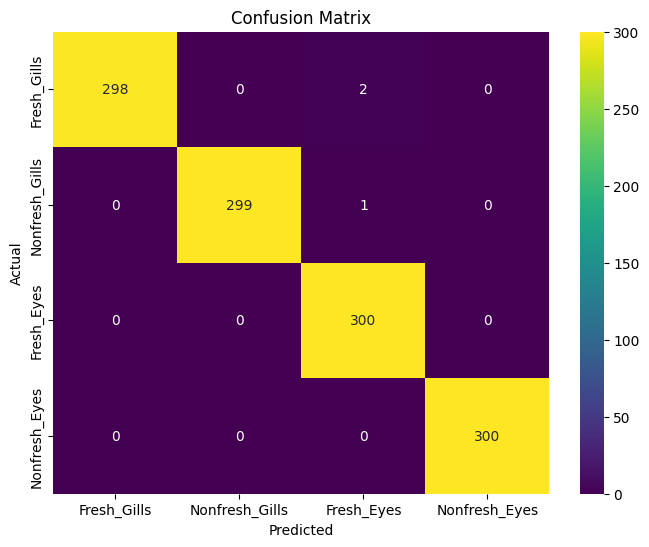

Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [49]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming you have already trained and compiled your model
# train_ds is your training dataset

# Make predictions using the trained model
predictions = model.predict(test_generator)

# Convert predicted probabilities to class labels
predicted_labels = np.argmax(predictions, axis=1)

# Get the actual labels from the dataset

# Calculate the confusion matrix
confusion_mtx = confusion_matrix(test_labels, predicted_labels)
classes = folders


import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# Assuming you have already trained and compiled your model
# train_ds is your training dataset
classes = folders

# Create a Seaborn heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='viridis',
            xticklabels=classes, yticklabels=classes)  # Replace 'classes' with your class labels
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

cm= confusion_mtx
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]


# Calculate metrics
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1_score = 2 * (precision * recall) / (precision + recall)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1_score)

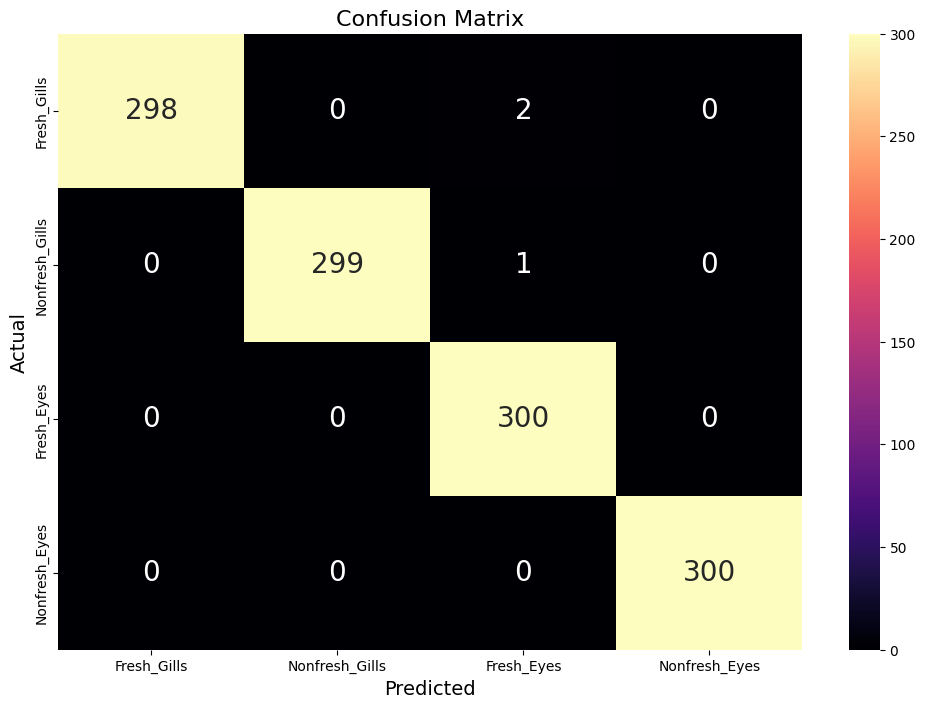

In [50]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

classes = folders

# Create a Seaborn heatmap for the confusion matrix
plt.figure(figsize=(12, 8))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='magma',
            xticklabels=classes, yticklabels=classes, annot_kws={"fontsize": 20})  # Adjust fontsize as needed
plt.xlabel('Predicted', fontsize=14)  # Adjust fontsize as needed
plt.ylabel('Actual', fontsize=14)  # Adjust fontsize as needed
plt.title('Confusion Matrix', fontsize=16)  # Adjust fontsize as needed
plt.savefig('images.pdf')
plt.show()


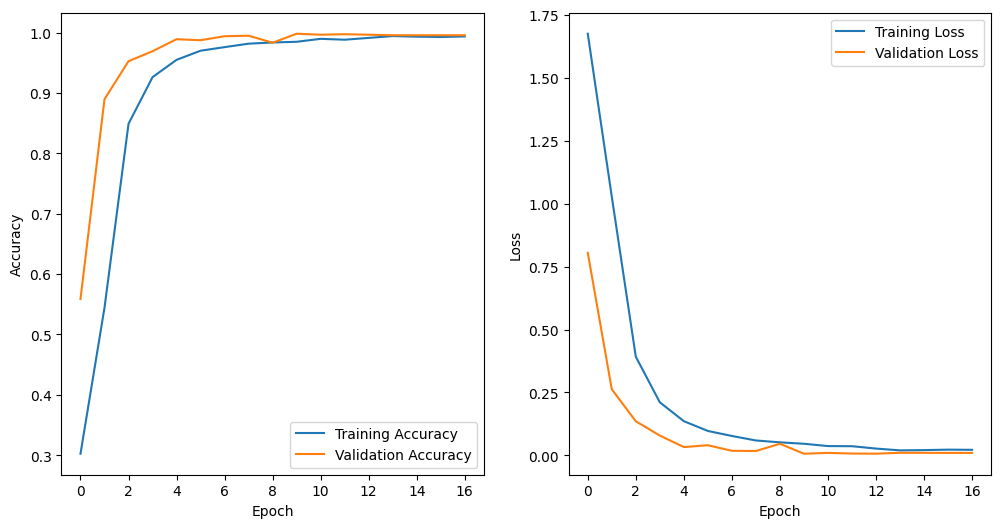

In [51]:
# prompt: print the validation and training curve

# Visualize training and validation curves

# Get the training and validation accuracy values from the model's history
train_accuracy = progress.history['accuracy']
val_accuracy = progress.history['val_accuracy']

# Get the training and validation loss values from the model's history
train_loss = progress.history['loss']
val_loss = progress.history['val_loss']

# Create a figure with two subplots
plt.figure(figsize=(12, 6))

# First subplot: Training and validation accuracy
plt.subplot(1, 2, 1)
plt.plot(train_accuracy, label='Training Accuracy')
plt.plot(val_accuracy, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Second subplot: Training and validation loss
plt.subplot(1, 2, 2)
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Show the plot
plt.show()


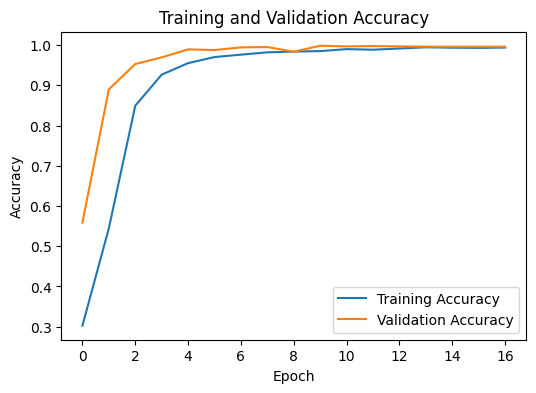

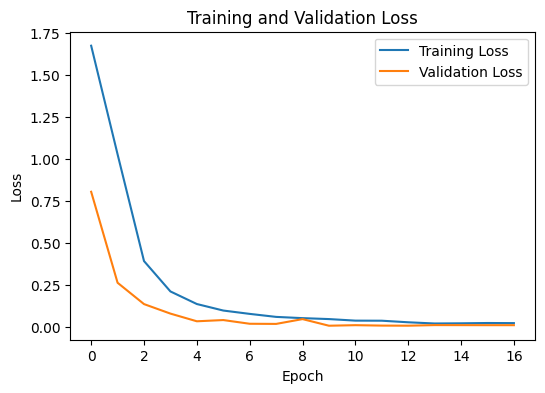

In [52]:
# prompt: print validation and accuracy curve sparately

# Visualize training and validation accuracy

# Get the training and validation accuracy values from the model's history
train_accuracy = progress.history['accuracy']
val_accuracy = progress.history['val_accuracy']

# Create a figure
plt.figure(figsize=(6, 4))

# Plot the training and validation accuracy
plt.plot(train_accuracy, label='Training Accuracy')
plt.plot(val_accuracy, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

# Show the plot
plt.show()


# Visualize training and validation loss

# Get the training and validation loss values from the model's history
train_loss = progress.history['loss']
val_loss = progress.history['val_loss']

# Create a figure
plt.figure(figsize=(6, 4))

# Plot the training and validation loss
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')

# Show the plot
plt.show()


In [53]:
# prompt: print the classification report

print(classification_report(test_generator.classes, np.argmax(model.predict(test_generator), axis=1), target_names=classes))


19/19 [==============================] - 15s 776ms/step
                precision    recall  f1-score   support

   Fresh_Gills       1.00      0.99      1.00       300
Nonfresh_Gills       1.00      1.00      1.00       300
    Fresh_Eyes       0.99      1.00      1.00       300
 Nonfresh_Eyes       1.00      1.00      1.00       300

      accuracy                           1.00      1200
     macro avg       1.00      1.00      1.00      1200
  weighted avg       1.00      1.00      1.00      1200



In [54]:
# prompt: print the precision, recall and f1 score

from sklearn.metrics import precision_score, recall_score, f1_score

# Assuming you have already evaluated your model and have the following variables:
# test_generator.classes: True labels
# model.predict(test_generator): Predicted probabilities
# classes: List of class names

# Calculate precision, recall, and F1-score for each class
precision = precision_score(test_generator.classes, np.argmax(model.predict(test_generator), axis=1), average=None, labels=range(len(classes)))
recall = recall_score(test_generator.classes, np.argmax(model.predict(test_generator), axis=1), average=None, labels=range(len(classes)))
f1 = f1_score(test_generator.classes, np.argmax(model.predict(test_generator), axis=1), average=None, labels=range(len(classes)))

# Print the results
for i, cls in enumerate(classes):
    print(f"Class {cls}:")
    print(f"Precision: {precision[i]:.4f}")
    print(f"Recall: {recall[i]:.4f}")
    print(f"F1-score: {f1[i]:.4f}")
    print()


19/19 [==============================] - 14s 751ms/step
Class Fresh_Gills:
Precision: 1.0000
Recall: 0.9933
F1-score: 0.9967

Class Nonfresh_Gills:
Precision: 1.0000
Recall: 0.9967
F1-score: 0.9983

Class Fresh_Eyes:
Precision: 0.9901
Recall: 1.0000
F1-score: 0.9950

Class Nonfresh_Eyes:
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000



19/19 [==============================] - 15s 756ms/step


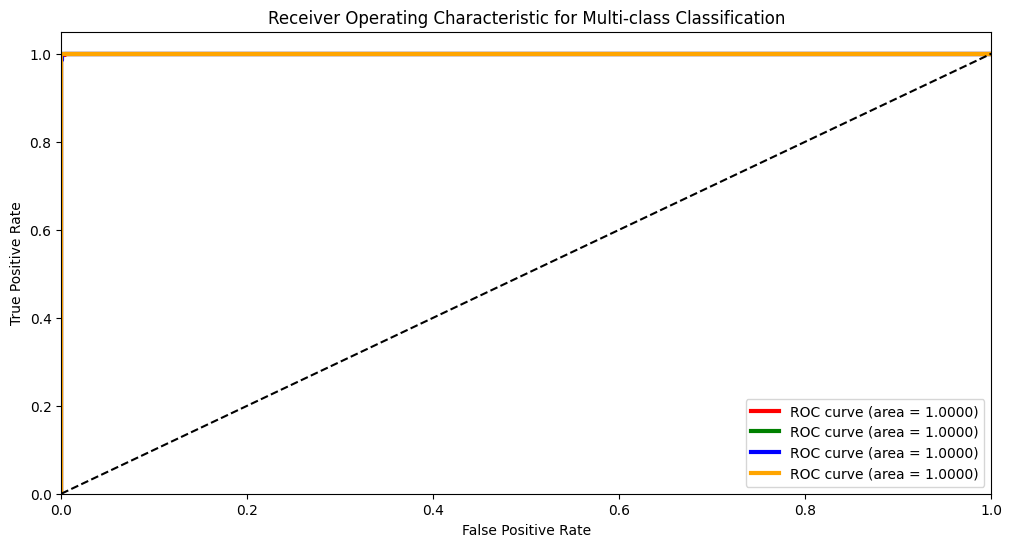

AUC scores:
Class 1: 0.9999851851851852
Class 2: 1.0
Class 3: 0.9999851851851852
Class 4: 1.0


In [55]:
# prompt: ROC Curve display for deep learning

# Get predicted probabilities for each class
predictions = model.predict(test_generator)

# Get the actual labels
test_labels = np.array(test_generator.labels)

# Binarize the test labels
test_labels_bin = keras.utils.to_categorical(test_labels)

# Calculate ROC curves and AUC for each class
fpr = {}
tpr = {}
auc_scores = {}

n_classes = 4  # Adjust this to your number of classes

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], predictions[:, i])
    auc_scores[i] = auc(fpr[i], tpr[i])

# Plot the ROC curves
plt.figure(figsize=(12, 6))


lw = 3
colors = ['red', 'green', 'blue', 'orange']  # Adjust colors for each class

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=lw,
             label='ROC curve (area = %0.4f)' % auc_scores[i])

plt.plot([0, 1], [0, 1], color='black', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic for Multi-class Classification')
plt.legend(loc="lower right")
plt.show()

# Print AUC scores
print('AUC scores:')
for i, score in auc_scores.items():
    print(f'Class {i+1}: {score}')


In [ ]:
model.save('Rui.h5')

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
